# Testing the routine of applying priors

In this notebook, I demonstrate how the prior can be included in the Bayesian Framework. This is a test function. If you encounter any issues, please contact Dingshan Deng.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# if you do not want to install ysoisochrone to your system PATH
# you can also use the following script to temporarily add the package to your PATH
# """
github_dir = '/Users/dingshandeng/github/ysoisochrone/'
sys.path.append(os.path.join(github_dir))
# """

import ysoisochrone

In [3]:
# Set up a DataFrame in Python script
# For this target Sz71, values are from Alcala+2017, 
# and corrected later with the Gaia DR3 distance in Manara+2023
df_prop = pd.DataFrame({
    'Source': ['Sz71'],
    'Teff[K]': np.array([3632.0]),
    'e_Teff[K]': np.array([167.0]),
    'Luminosity[Lsun]': np.array([0.327]),
    'e_Luminosity[Lsun]': np.array([0.1420])
})

## For the case assuming ages

In [4]:
# 1) No prior (flat in log-mass): same as before
ysoisochrone.bayesian.derive_stellar_mass_assuming_age(df_prop, assumed_age=1e6)

array([[-0.4 , -0.51, -0.31]])

In [5]:
# 2) Gaussian prior in log-mass (center 0.0 dex = 1 Msun, sigma 0.2 dex)
prior_mass = lambda logm: np.exp(-0.5*((logm - 0.0)/0.2)**2)
ysoisochrone.bayesian.derive_stellar_mass_assuming_age(df_prop, assumed_age=1e6, prior_mass=prior_mass)

array([[-0.32, -0.41, -0.24]])

## For the case that I have the mass as prior

  0%|          | 0/1 [00:00<?, ?it/s]

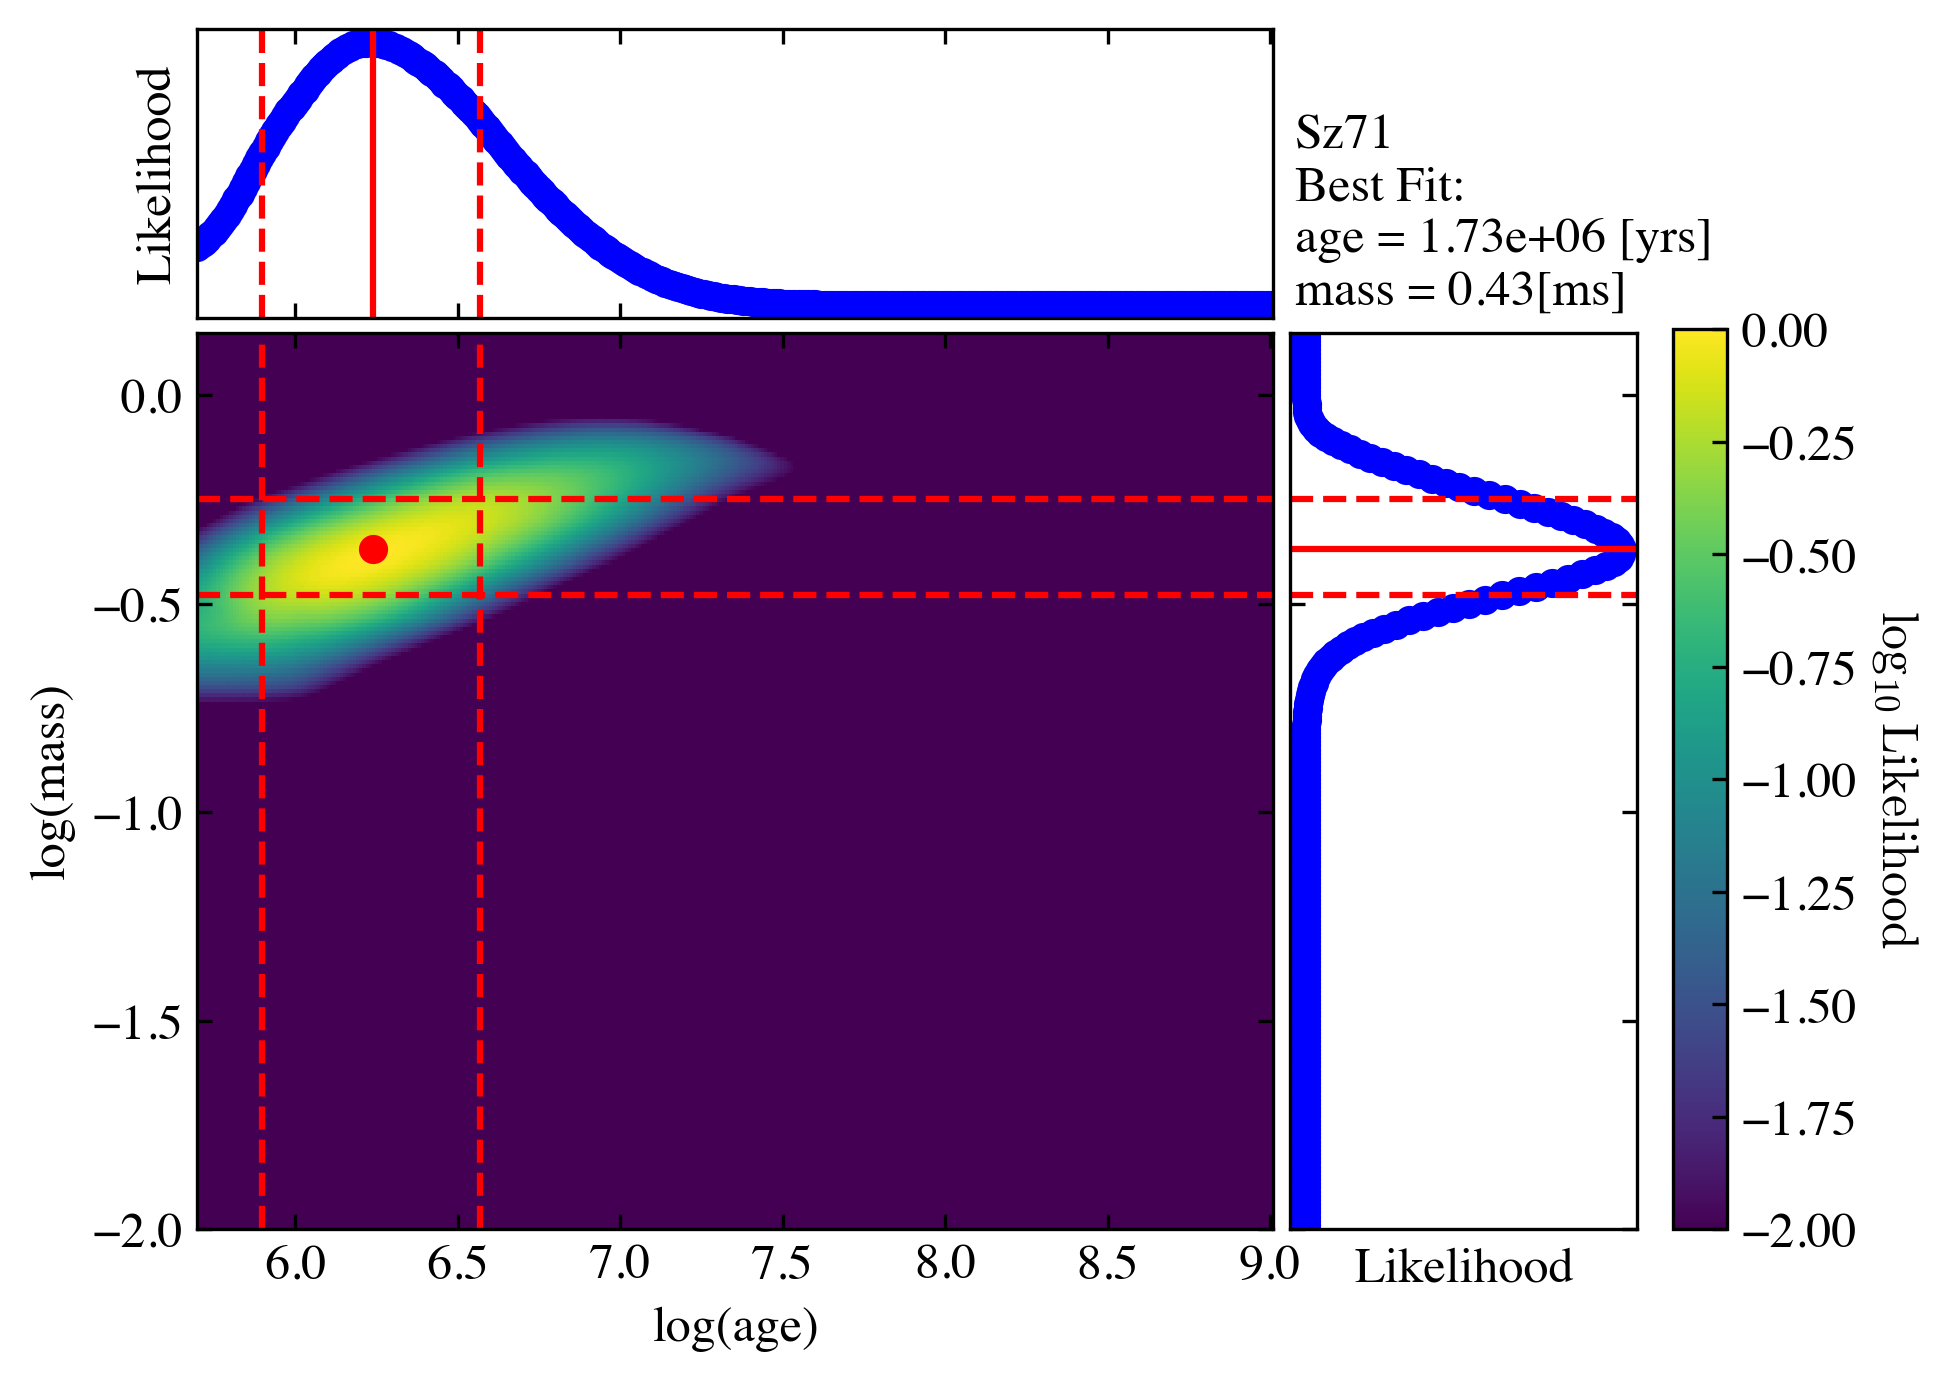

100%|██████████| 1/1 [00:00<00:00,  3.21it/s]


In [9]:
# 1) without any prior
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True)

  0%|          | 0/1 [00:00<?, ?it/s]

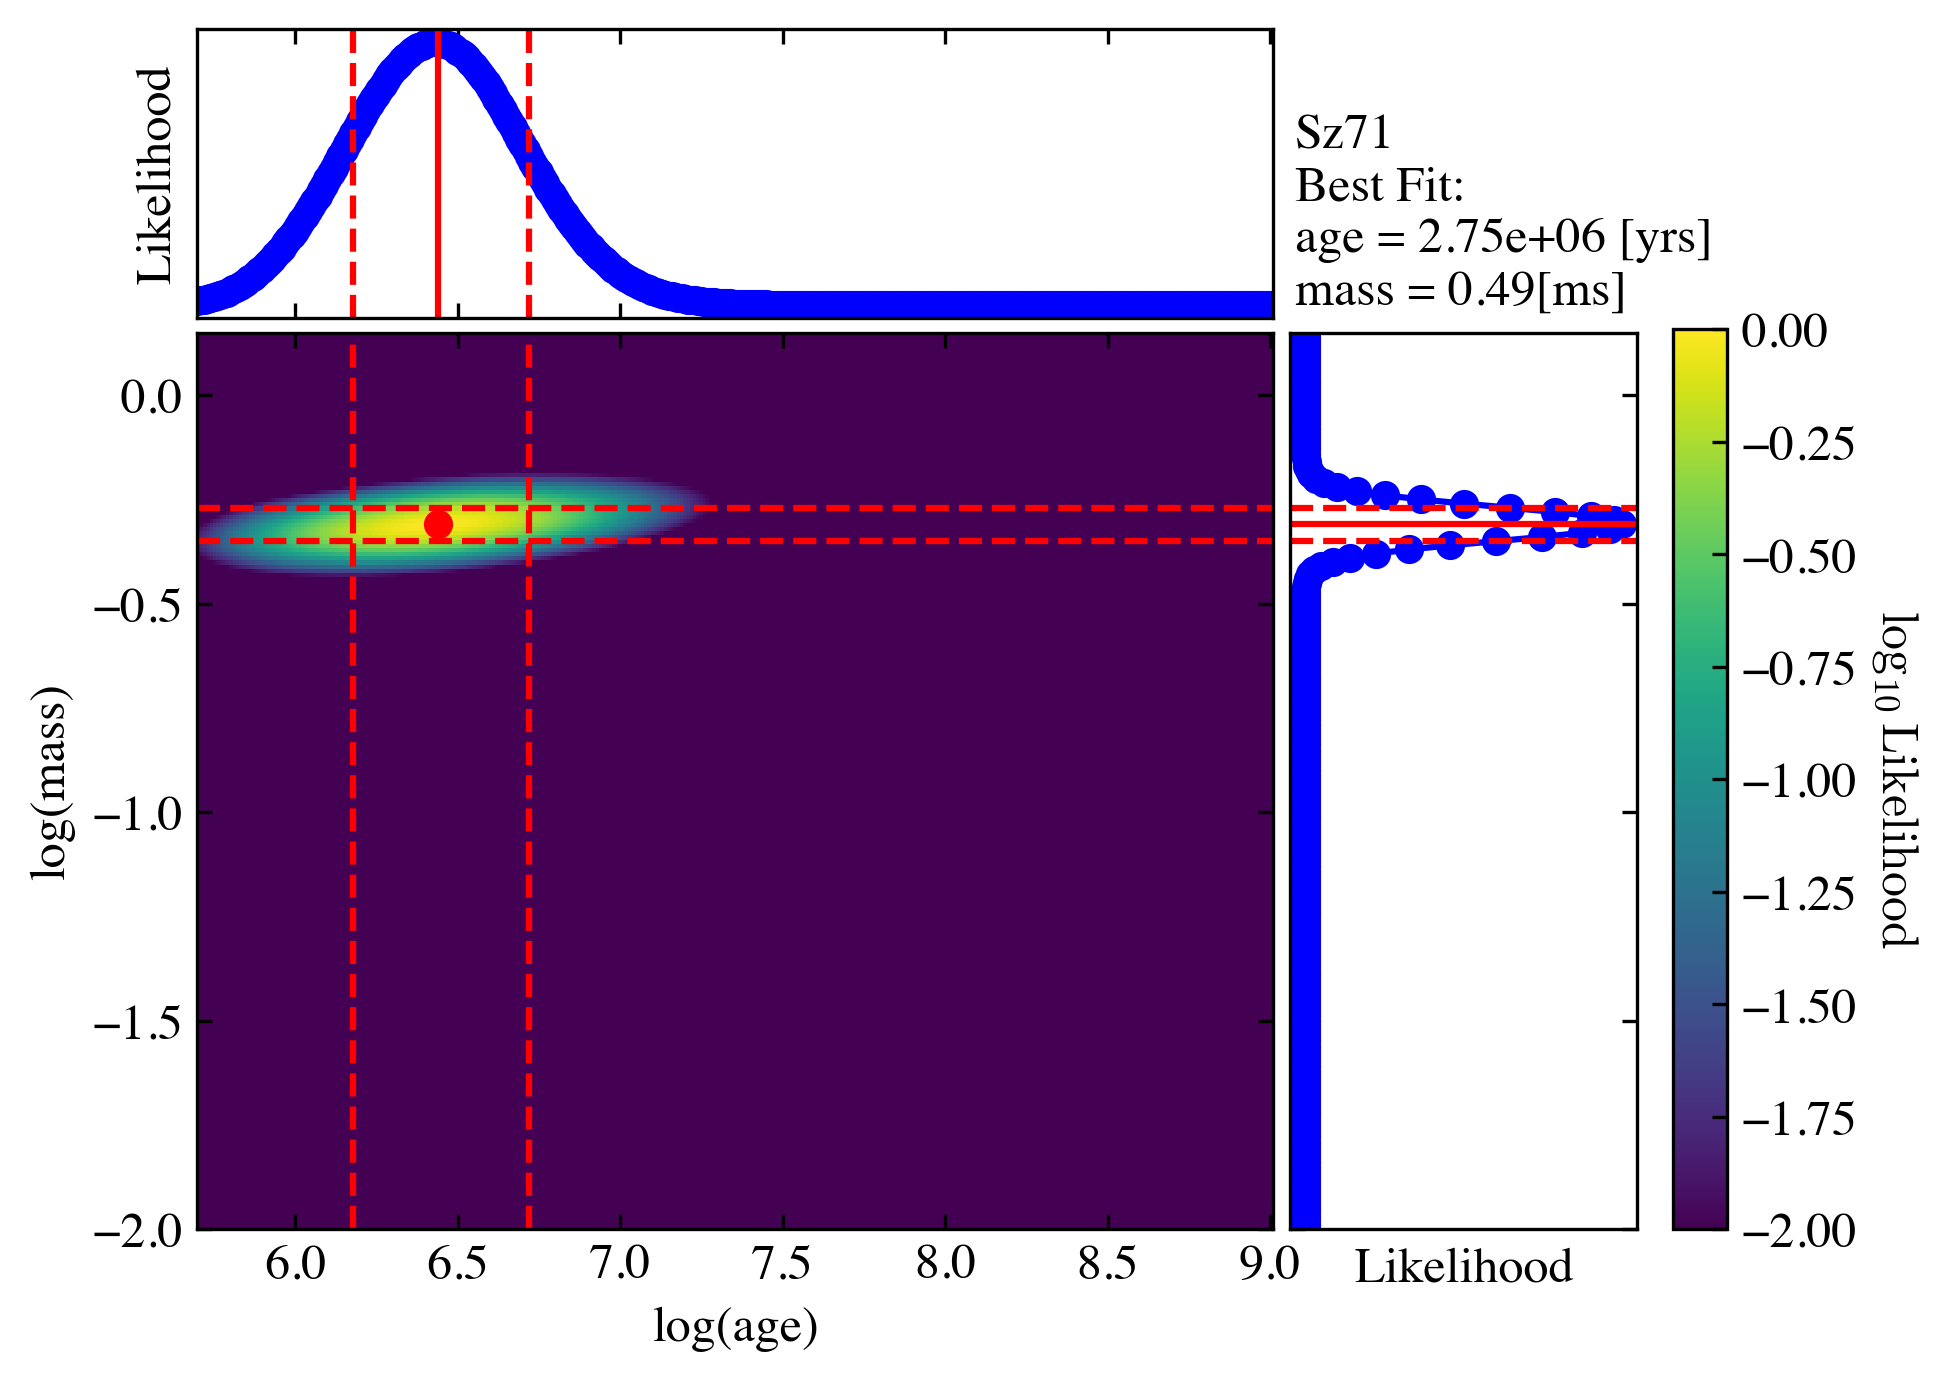

100%|██████████| 1/1 [00:00<00:00,  4.27it/s]


In [12]:
# 2) A Gaussian Prior
# Gaussian prior in *linear* mass (Msun), μ = 0.5 Msun, σ = 0.1 Msun
mu_logm = np.log10(0.5)            # log10(0.5 Msun)
sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun
prior_mass = lambda logm: np.exp(-0.5*((logm - mu_logm)/sigma_logm)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_mass=prior_mass)

Other priors

for example, if the age prior is also used

  0%|          | 0/1 [00:00<?, ?it/s]

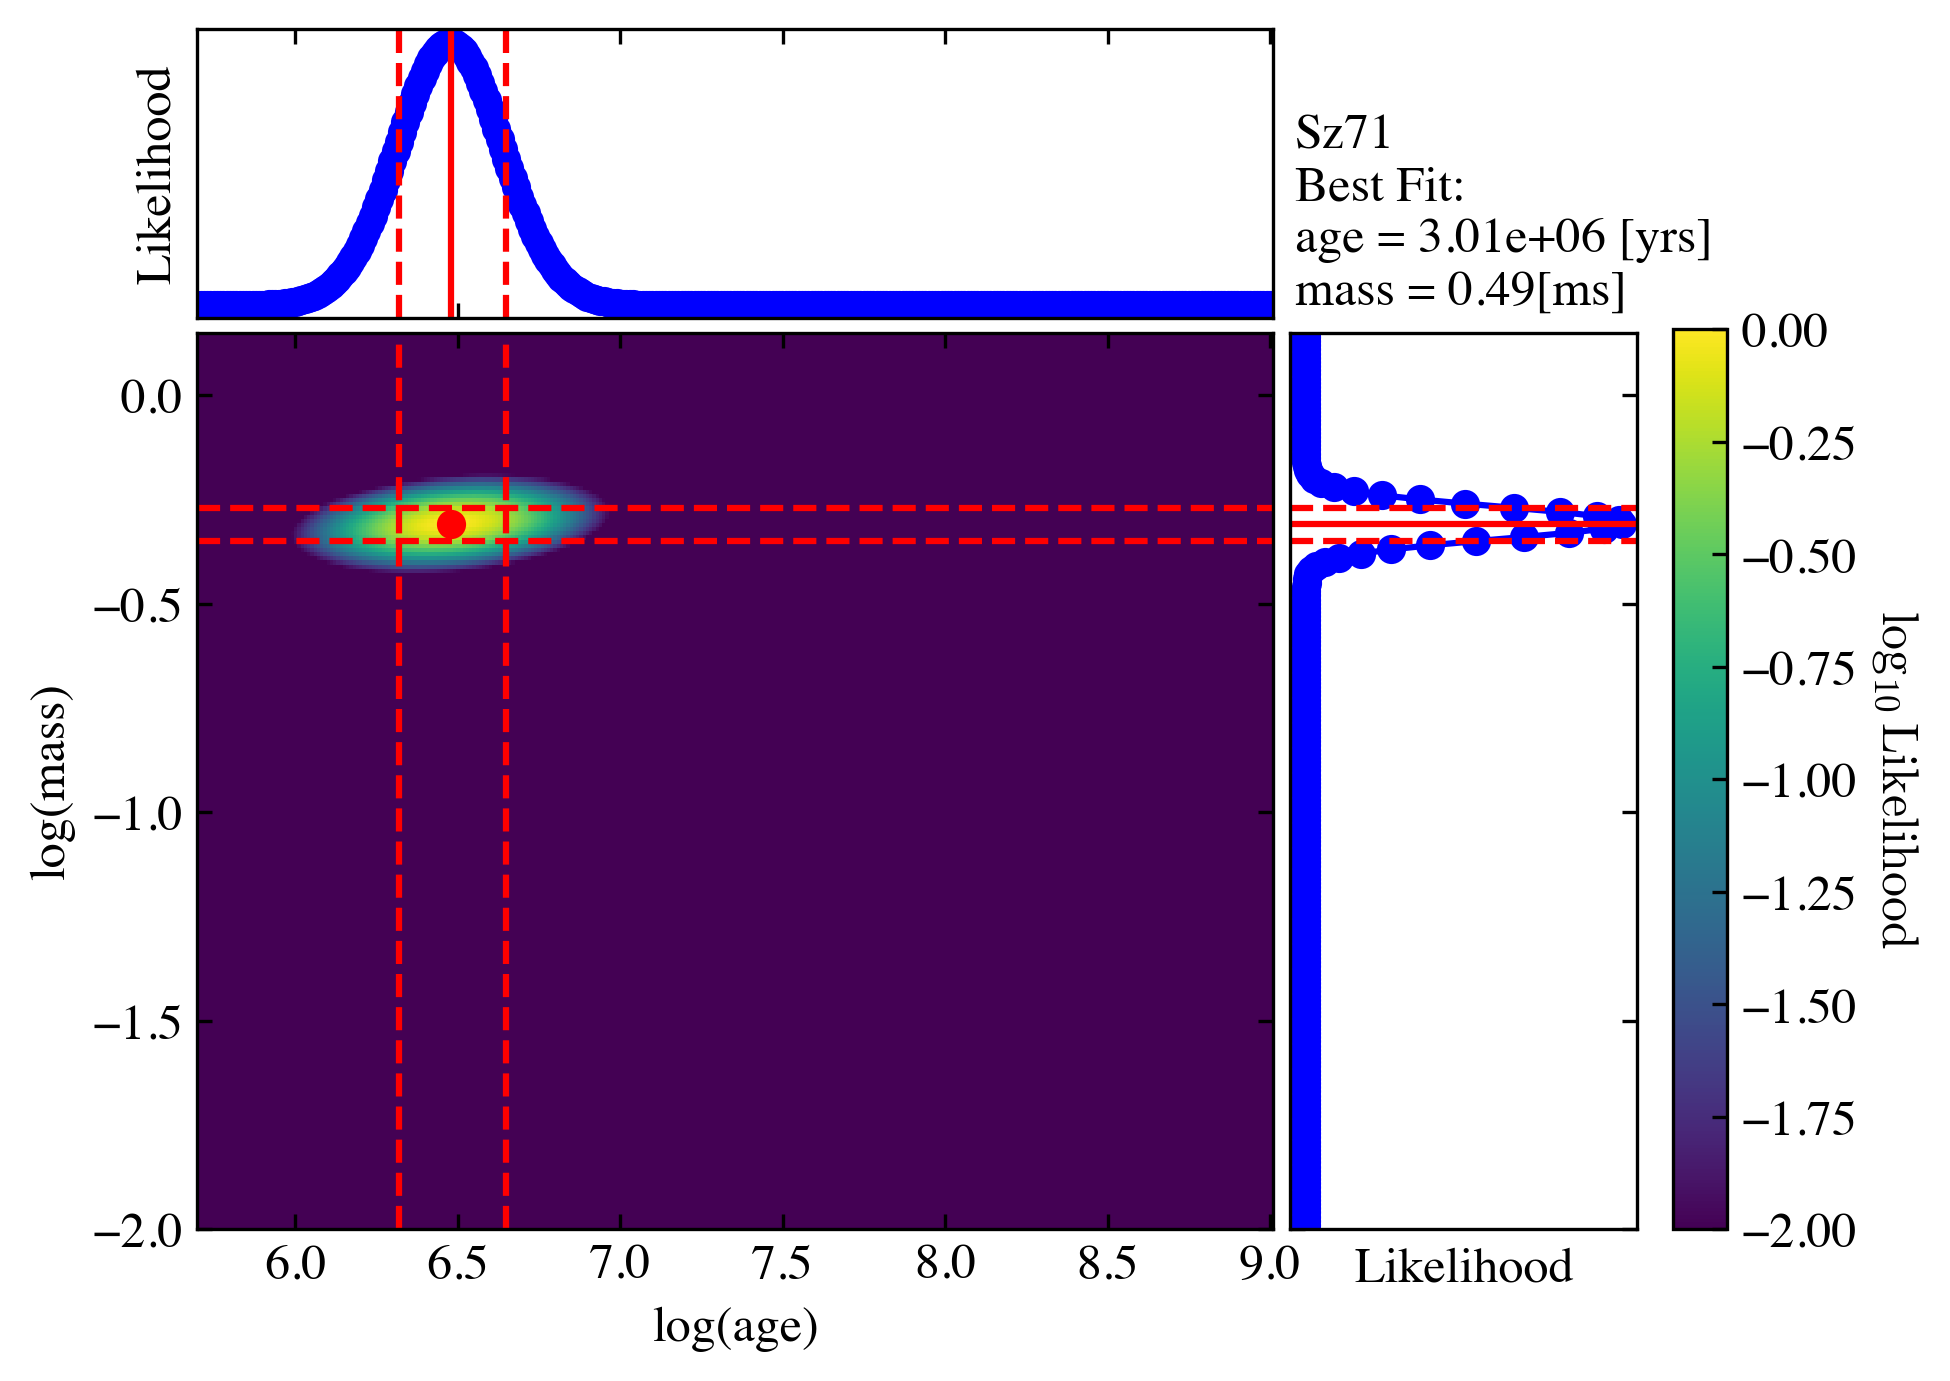

100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


In [15]:
# 3) together with age_prior, you can also only use age_prior
# Gaussian prior in *linear* mass (Msun), μ = 0.5 Msun, σ = 0.1 Msun
mu_logm = np.log10(0.5)            # log10(0.5 Msun)
sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun
prior_mass = lambda logm: np.exp(-0.5*((logm - mu_logm)/sigma_logm)**2)

# Gaussian prior on log(age/yr) centered at 6.5 with σ=0.2 dex:
mu_logage = 6.5
sigma_logage = 0.2
prior_age = lambda logage: np.exp(-0.5*((logage - mu_logage)/sigma_logage)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_mass=prior_mass,
        prior_age =prior_age)

  0%|          | 0/1 [00:00<?, ?it/s]

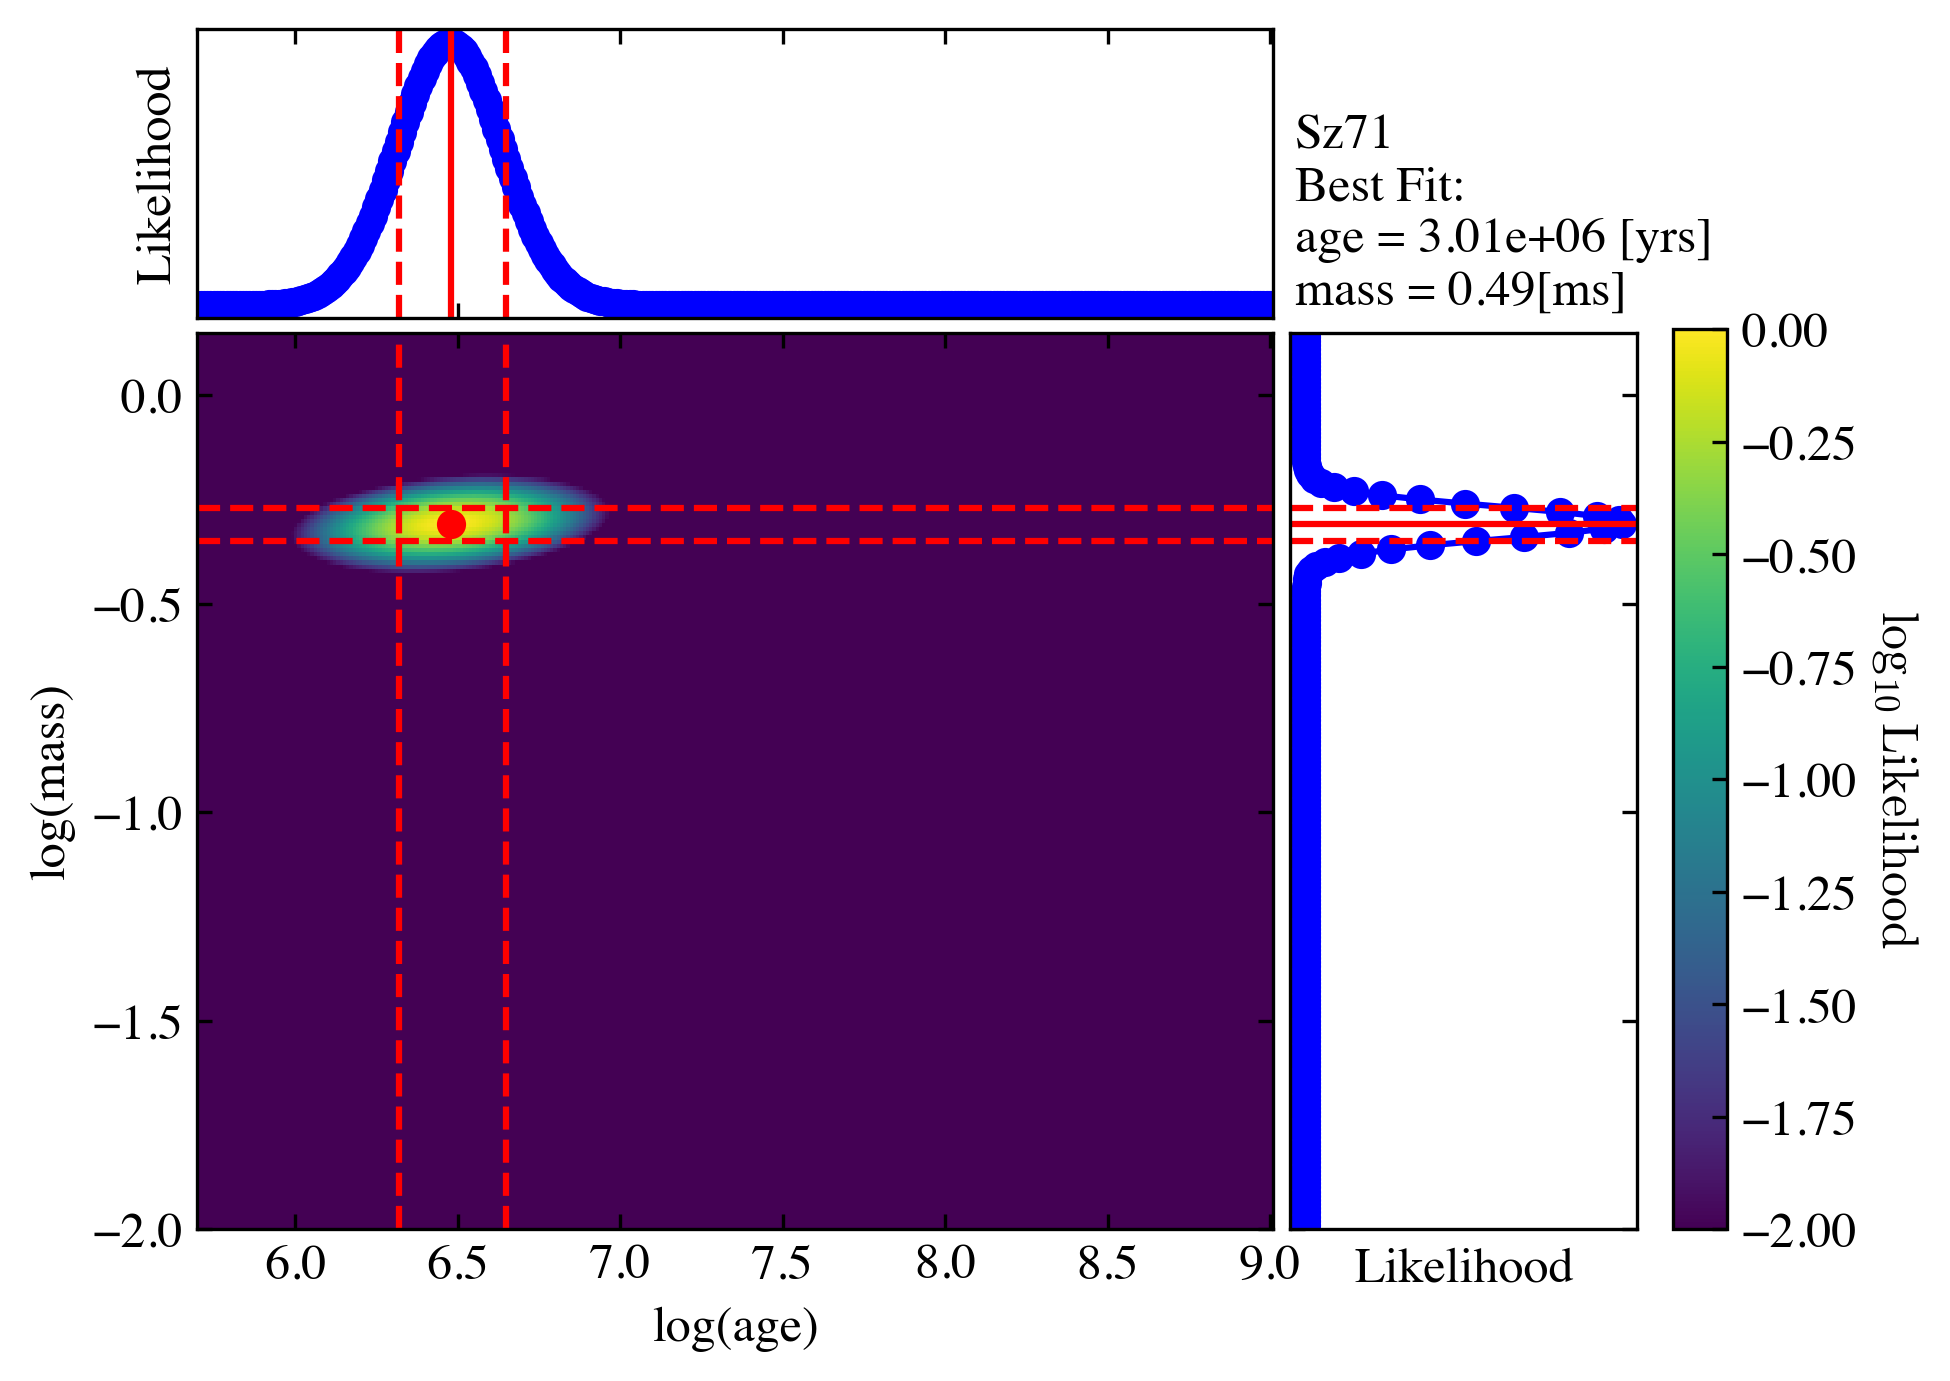

100%|██████████| 1/1 [00:00<00:00,  4.14it/s]


In [16]:
# 4) define a joint prior as a callable
# if you use this option, DO NOT use prior_age or prior_mass

# This is just an example for the fun_joint_prior
# it can be any function that you defined as long as it is 
# a callable to (logage, logmass)
def func_joint_prior(logage, logmass):
    # shapes like the meshgrid (Na, Nm)
    mu_logm = np.log10(0.5)            # log10(0.5 Msun)
    sigma_logm = 0.1 / (np.log(10))    # ≈ 0.0434 dex for 10% at 1 Msun

    # Gaussian prior on log(age/yr) centered at 6.5 with σ=0.2 dex:
    mu_logage = 6.5
    sigma_logage = 0.2
    
    return np.exp(-0.5*((logmass-mu_logm)/sigma_logm)**2) * np.exp(-0.5*((logage-mu_logage)/sigma_logage)**2)

# Pass this prior mass into the routine
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(
        df_prop,
        model='Baraffe_n_Feiden',
        plot=True,
        prior_joint=func_joint_prior
        )